In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

archivo_dem = 'Tenerife.tif'

# Se lee el raster, se guarda en elev los datos relativos a altura (modificando aquellos datos ausentes)
# Se guarda también el número de filas, columnas y la matriz de transformaciones

with rasterio.open(archivo_dem) as dataset:
  elev = dataset.read(1)
  elev = np.where(elev == dataset.nodata, np.nan, elev)
  nrows, ncols = elev.shape
  transform = dataset.transform

# Se usa la matriz de transformaciones para pasar de coordinadas reales a píxeles de la foto

x = transform[2] + np.arange(ncols) * transform[0]
y = transform[5] + np.arange(nrows) * transform[4]
xs, ys = np.meshgrid(x, y)

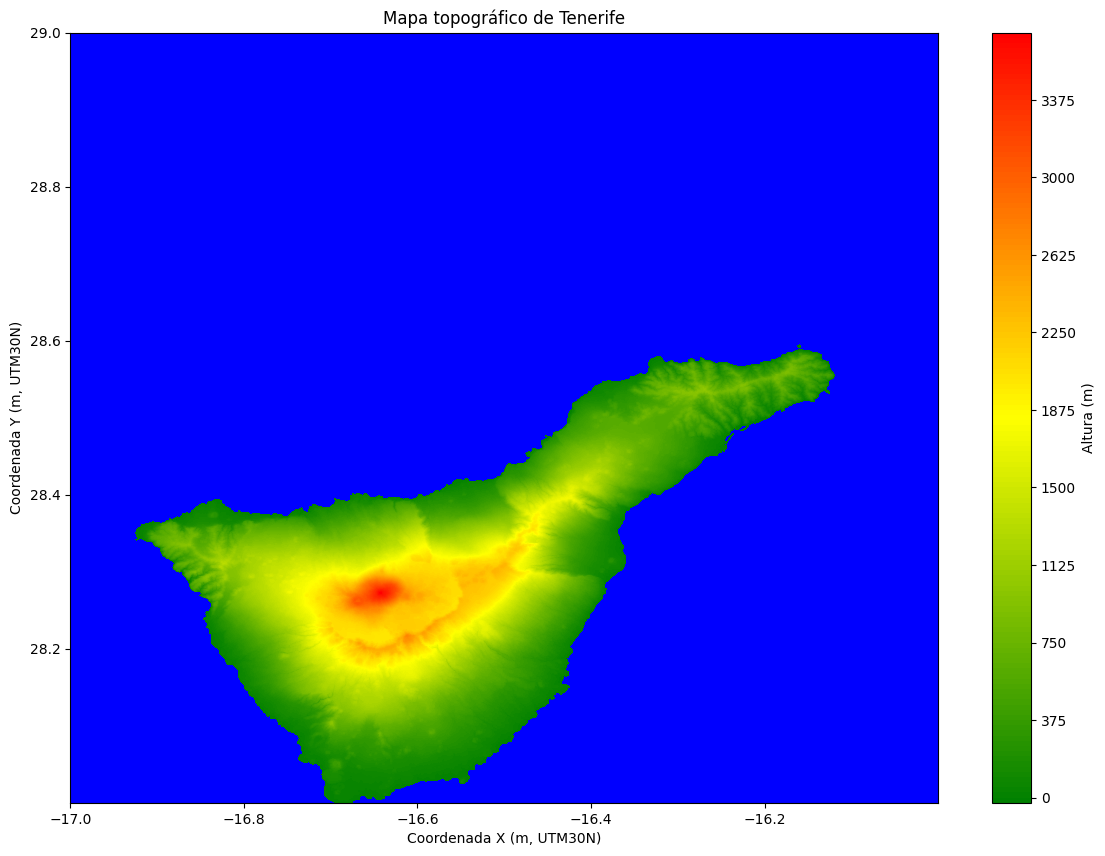

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

elev_plot = elev.copy()

# Se modifican aquellos datos que sean 0 a nan para poder modificar la altura 0 al color azul.
elev_plot[elev_plot == 0] = np.nan

# Se define un colormap que establecerá el color de cada píxel

cmap = LinearSegmentedColormap.from_list(
    "gyr",
    ["green", "yellow", "red"]
)

# Se define el tamaño de la figura

plt.figure(figsize=(14, 10))

# Se define que los datos que faltan (NaN o bien 0, que se han establecido a NaN) sean azules. Perfecto
# para representar el agua

ax = plt.gca()
ax.set_facecolor("blue")   

# Se dibuja la gráfica

cp = plt.contourf(
    xs, ys, elev_plot,
    levels=150,
    cmap=cmap
)

# Se define la barra de colores y los contornos separando los distintos niveles de altura. Se definen 20 niveles (puede ser cualquier número)

plt.colorbar(cp, label='Altura (m)')
plt.contour(xs, ys, elev_plot, colors='black', linewidths=0.5, levels=20)

# Se define el título de gráfica y las coordenadas. El sistema UTM define el sistema de coordinadas usadas

plt.title('Mapa topográfico de Tenerife')
plt.xlabel('Coordenada X (m, UTM30N)')
plt.ylabel('Coordenada Y (m, UTM30N)')

plt.show()

In [4]:
print(norm)